**4th ML Model: XGBoost**

Name: Alphin Varghese

In [ ]:
import gc, os
from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
df =pd.read_csv("train.csv")
print("raw shape:", df.shape)
display(df.head())

df2 =df.copy()

raw shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
def g_collect(vs):
    for v in vs:
        if v in globals():
            del globals()[v]
    gc.collect()

def err_fun(y, y_hat):
    return y -y_hat

def mse(y, y_hat):
    e =err_fun(y, y_hat)
    return np.mean(e**2)

def rmse(y, y_hat):
    return np.sqrt(mse(y, y_hat))

def mae(y, y_hat):
    e =np.abs(y - y_hat)
    return np.mean(e)

def sse(y, y_hat):
    e =err_fun(y, y_hat)
    return np.sum(e**2)

def perf(y, y_hat):
    e =err_fun(y, y_hat)
    ss =np.sum(e**2)
    return e, ss, mse(y, y_hat), rmse(y, y_hat), mae(y, y_hat)


In [ ]:
if "GrLivArea" in df2.columns and "SalePrice" in df2.columns:
    m_before = df2.shape[0]
    mask_big = (df2["GrLivArea"] > 4000) & (df2["SalePrice"] < 300000)
    df2 = df2.loc[~mask_big].reset_index(drop=True)
    print("rows removed:", m_before - df2.shape[0])

sp =df2["SalePrice"].values.astype(float)
mu_sp =sp.mean()
sd_sp = sp.std() if sp.std() != 0 else 1.0
z_sp =(sp -mu_sp) / sd_sp
keep = np.abs(z_sp) < 3.5
print("keeping rows:", keep.sum(), "out of",len(keep))
df2 = df2.loc[keep].reset_index(drop=True)

print("cleaned shape:", df2.shape)

y =df2["SalePrice"].astype(float)
X =df2.drop(["SalePrice"], axis=1)

if "Id" in X.columns:
    X = X.drop(["Id"],axis=1)

num_cols =X.select_dtypes(include=["int64","float64"]).columns
cat_cols =X.select_dtypes(include=["object"]).columns

for c in num_cols:
    X[c] =X[c].fillna(X[c].median())

for c in cat_cols:
    X[c] =X[c].fillna("None")

X_all = pd.get_dummies(X, columns=list(cat_cols),drop_first=True)
print("X_all shape after dummies:", X_all.shape)

rows removed: 2
keeping rows: 1445 out of 1458
cleaned shape: (1445, 81)
X_all shape after dummies: (1445, 259)


In [ ]:
from sklearn.model_selection import train_test_split

X_trn, X_tst, y_trn, y_tst =train_test_split(X_all,y,test_size=0.2,random_state=42)
print("X trn:", X_trn.shape, "X tst:", X_tst.shape)

X trn: (1156, 259) X tst: (289, 259)


In [ ]:
from xgboost import XGBRegressor

In [ ]:
Xtr =X_trn.values
Xt =X_tst.values
ytr =y_trn.values
yt =y_tst.values

xgb_best = XGBRegressor(
    n_estimators =500,
    max_depth = 3,
    learning_rate =0.05,
    subsample =0.8,
    colsample_bytree =0.8,
    reg_lambda =1.0,
    objective = "reg:squarederror",
    random_state =0,
    n_jobs =-1
)

In [ ]:
xgb_best.fit(Xtr, ytr)

y_hat_tr =xgb_best.predict(Xtr)
y_hat_ts =xgb_best.predict(Xt)

tr_err,tr_sse, tr_mse,tr_rmse, tr_mae =perf(ytr, y_hat_tr)
ts_err,ts_sse, ts_mse,ts_rmse, ts_mae =perf(yt, y_hat_ts)

mean_price_tr =ytr.mean()
mean_price_ts =yt.mean()
tr_loss_ratio =tr_mae /mean_price_tr
ts_loss_ratio =ts_mae /mean_price_ts
tr_acc_ratio = 1.0 -tr_loss_ratio
ts_acc_ratio = 1.0 -ts_loss_ratio
print("Train MSE:", tr_mse)
print("Test  MSE:", ts_mse)
print("Train RMSE:", tr_rmse)
print("Test  RMSE:", ts_rmse)
print("Train MAE:", tr_mae)
print("Test  MAE:", ts_mae)
print("Train loss ratio:", tr_loss_ratio)
print("Test  loss ratio:", ts_loss_ratio)
print("Train accuracy ratio:", tr_acc_ratio)
print("Test  accuracy ratio:", ts_acc_ratio)

Train MSE: 83841299.66275668
Test  MSE: 364359249.05442923
Train RMSE: 9156.489483571566
Test  RMSE: 19088.196589893694
Train MAE: 6821.941629271194
Test  MAE: 13310.492782223184
Train loss ratio: 0.038009965813469826
Test  loss ratio: 0.07856654615477623
Train accuracy ratio: 0.9619900341865302
Test  accuracy ratio: 0.9214334538452238


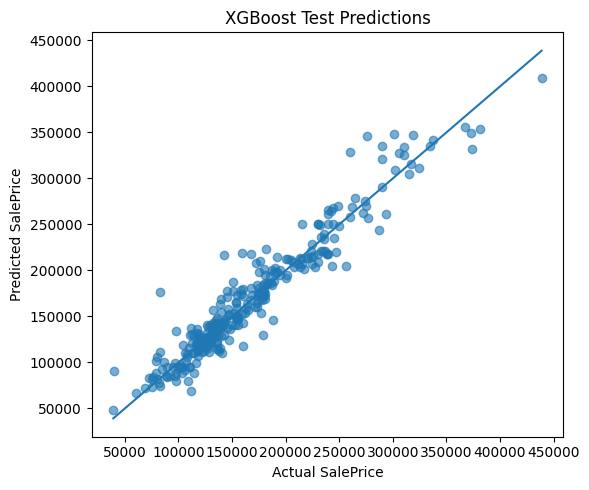

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(yt, y_hat_ts, alpha=0.6)
mn = min(yt.min(), y_hat_ts.min())
mx = max(yt.max(), y_hat_ts.max())
plt.plot([mn,mx],[mn,mx])
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("XGBoost Test Predictions")
plt.tight_layout()
plt.show()